# Notebook 04 — Ajuste, evaluación final y exportación

**Proyecto final de Fundamentos de Inteligencia Artificial · Universidad EIA (2026-2)**

En este notebook cerramos el modelado: ajustamos los hiperparámetros de las 3 mejores combinaciones del notebook 03, escogemos el modelo final, decidimos su umbral de decisión, lo evaluamos **una sola vez** en el conjunto de test y lo exportamos para la app.

Reglas que seguimos: el modelo final se elige por su F1 en validación cruzada, **nunca** por lo que salga en test; el umbral se elige con predicciones de validación cruzada sobre train; y `test.csv` no se lee hasta la sección de evaluación final.

**Nota importante: este notebook tuvo una primera versión que descartamos.** La primera versión siguió el plan al pie de la letra: ajustar los hiperparámetros con `scoring='f1'` y luego elegir el umbral. Ganó la regresión logística con submuestreo y `C=0,01`, con F1 de 0,296 en test (20 de 34 turnos peligrosos detectados y 81 falsas alarmas). Pero el modelo estaba tan regularizado que casi todas sus probabilidades quedaban entre 0,49 y 0,56, y el umbral funcionaba en un borde tan fino (con 0,49 marcaba todo como peligroso y con 0,51 el F1 caía) que la app no habría podido mostrar un riesgo con sentido. Ese problema lo vimos con los datos de train (las probabilidades de validación cruzada), no por el resultado en test. Aun así, **ese primer resultado en test ya lo habíamos visto**, y lo decimos aquí para que se sepa: el test de esta versión ya no es completamente virgen. Cambiamos el enfoque para tener un modelo que funcione bien (probabilidades calibradas que se puedan interpretar), no para subir el número de test.

Los cambios son dos: ajustamos los hiperparámetros con la precisión promedio, que no depende del umbral, y calibramos las probabilidades de cada modelo antes de elegir el umbral.

Deja listos `models/modelo_final.joblib`, `models/metadata_modelo.json` y `resultados/ajuste_hiperparametros.csv`.

In [1]:
# Si corremos en Google Colab ponemos True; en el computador (VS Code), False
EN_COLAB = False

if EN_COLAB:
    # En Colab hay que instalar lo que no viene de fábrica, y se repite en cada sesión nueva
    !pip install phik shap gradio imbalanced-learn -q
    # En Colab los archivos viven en Drive, así que primero lo montamos
    from google.colab import drive
    drive.mount('/content/drive')
    RUTA_BASE = '/content/drive/MyDrive/Proyecto_Sismos/'
else:
    RUTA_BASE = './'

# Todas las rutas del notebook salen de aquí, para no tener rutas regadas por el código
RUTA_DATOS = RUTA_BASE + 'data/'
RUTA_MODELOS = RUTA_BASE + 'models/'
RUTA_RESULTADOS = RUTA_BASE + 'resultados/'
RUTA_FIGURAS = RUTA_BASE + 'figuras/'

In [2]:
import os
import time
import json
import joblib
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict, GridSearchCV
from sklearn.metrics import (make_scorer, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
                             classification_report, confusion_matrix, average_precision_score, brier_score_loss,
                             ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import (RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, StackingClassifier)

# Por si las carpetas de salida no existen (por ejemplo, en una carpeta nueva de Drive)
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_RESULTADOS, exist_ok=True)
os.makedirs(RUTA_FIGURAS, exist_ok=True)

## Cargar los datos de entrenamiento y las decisiones anteriores

Leemos `train.csv`, las decisiones del notebook 02 (escalador y rasgos) y la tabla de resultados del notebook 03. **Todavía no leemos `test.csv`**: lo vamos a abrir solo en la sección de evaluación final.

In [3]:
train = pd.read_csv(RUTA_DATOS + 'train.csv')
decisiones = joblib.load(RUTA_MODELOS + 'decisiones_preprocesamiento.joblib')
tabla_modelos = pd.read_csv(RUTA_RESULTADOS + 'comparacion_modelos.csv')

X_train = train[decisiones['rasgos']]
y_train = train['class']

print('Escalador:', decisiones['escalador'])
print('Rasgos:', decisiones['rasgos'])
print('X_train:', X_train.shape, '| turnos peligrosos:', y_train.sum())

Escalador: MinMaxScaler
Rasgos: ['gpuls', 'nbumps', 'nbumps2', 'nbumps3', 'energy']
X_train: (2062, 5) | turnos peligrosos: 136


Copiamos, **idénticas a las de los notebooks 02 y 03**, la validación cruzada, las métricas y las funciones `evaluar_cv`, `crear_modelos`, `crear_escalador`, `admite_class_weight` y `crear_pipeline`. Así una combinación de modelo y estrategia se arma exactamente igual que en la comparación. Al final agregamos `buscar_modelo`, que recorre el catálogo y devuelve el modelo con un nombre dado.

In [4]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Con tan pocos turnos peligrosos, a veces un modelo no predice ninguno en una partición y la precisión
# queda indefinida (scikit-learn lanza una advertencia). Con zero_division=0 la contamos como 0 y seguimos.
metricas = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
}

def evaluar_cv(pipeline, X, y, nombre):
    """
    Evalúa un pipeline con validación cruzada estratificada de 10 particiones.
    Devuelve un diccionario con el promedio de cada métrica, la desviación del F1, el F1 de cada
    partición (para los box plots) y el tiempo que tardó. Se agrega a la lista rows para armar la tabla.
    """
    inicio = time.time()
    resultados = cross_validate(pipeline, X, y, cv=cv, scoring=metricas, n_jobs=-1)
    return {
        'Nombre': nombre,
        'Accuracy': resultados['test_accuracy'].mean(),
        'Precision': resultados['test_precision'].mean(),
        'Recall': resultados['test_recall'].mean(),
        'F1': resultados['test_f1'].mean(),
        'F1_std': resultados['test_f1'].std(),
        'ROC_AUC': resultados['test_roc_auc'].mean(),
        'F1_por_particion': resultados['test_f1'],
        'Tiempo_s': time.time() - inicio,
    }

def crear_modelos():
    """
    Devuelve los 12 modelos que comparamos, como parejas (nombre, modelo sin entrenar).
    Son los mismos que vimos en clase. Si queremos probar otro, basta con agregar una línea aquí;
    el resto del notebook no cambia.
    """
    modelos = [
        ('KNN', KNeighborsClassifier(n_neighbors=5)),
        ('Naive Bayes', GaussianNB()),
        ('Árbol de decisión', DecisionTreeClassifier(random_state=42)),
        ('Regresión logística', LogisticRegression(max_iter=2000, random_state=42)),
        ('SVM', SVC(random_state=42)),
        ('SVM lineal', LinearSVC(max_iter=10000, random_state=42)),
        ('Red neuronal (MLP)', MLPClassifier(max_iter=1000, random_state=42)),
        ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('Bagging', BaggingClassifier(random_state=42)),
        ('AdaBoost', AdaBoostClassifier(random_state=42)),
        ('Gradient Boosting', GradientBoostingClassifier(random_state=42)),
        ('Stacking', StackingClassifier(
            estimators=[('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
                        ('svm', SVC(random_state=42)),
                        ('knn', KNeighborsClassifier(n_neighbors=5))],
            final_estimator=LogisticRegression(max_iter=2000),
            cv=5)),
    ]
    return modelos

def crear_escalador(nombre):
    """Devuelve un escalador nuevo según el nombre que guardamos en el notebook 02."""
    if nombre == 'MinMaxScaler':
        return MinMaxScaler()
    elif nombre == 'StandardScaler':
        return StandardScaler()
    return 'passthrough'   # 'Sin escalar': el pipeline deja pasar los datos tal cual

def admite_class_weight(modelo):
    """
    Dice si el modelo tiene el parámetro class_weight. KNN, Naive Bayes, MLP, Bagging, AdaBoost,
    Gradient Boosting y Stacking no lo tienen, así que con ellos esa estrategia no aplica.
    """
    return 'class_weight' in modelo.get_params()

def crear_pipeline(modelo, estrategia, nombre_escalador):
    """
    Arma el pipeline de una combinación modelo + estrategia: escalador -> (SMOTE o submuestreo) -> modelo.
    Usamos el Pipeline de imblearn porque así el balanceo se hace solo con los datos de entrenamiento
    de cada partición y nunca con los de validación; si no, los resultados saldrían inflados.
    """
    modelo = clone(modelo)   # copia limpia, para que una combinación no afecte a la siguiente
    pasos = [('escalador', crear_escalador(nombre_escalador))]
    if estrategia == 'SMOTE':
        pasos.append(('balanceo', SMOTE(random_state=42)))
    elif estrategia == 'Submuestreo':
        pasos.append(('balanceo', RandomUnderSampler(random_state=42)))
    elif estrategia == 'class_weight':
        modelo.set_params(class_weight='balanced')
    pasos.append(('clf', modelo))
    return ImbPipeline(pasos)

def buscar_modelo(nombre):
    """
    Recorre el catálogo de crear_modelos() y devuelve el modelo (sin entrenar) que tiene ese nombre.
    Si el nombre no existe, devuelve None.
    """
    for nombre_modelo, modelo in crear_modelos():
        if nombre_modelo == nombre:
            return modelo
    return None

## Grillas de hiperparámetros

Para ajustar los modelos con `GridSearchCV` necesitamos una grilla por modelo. Las guardamos todas en una función, así el notebook funciona sin importar cuáles queden entre los 3 mejores. Las grillas son pequeñas a propósito, porque con tan pocos turnos peligrosos una búsqueda muy grande se ajustaría al ruido. Todos los nombres llevan el prefijo `clf__`, que es el nombre del paso del modelo dentro del pipeline; si la estrategia es SMOTE, también probamos el número de vecinos de SMOTE (`balanceo__k_neighbors`).

In [5]:
def obtener_grilla(nombre_modelo, estrategia):
    """
    Devuelve la grilla de hiperparámetros del modelo para usar con GridSearchCV, como un diccionario.
    Recibe el nombre del modelo (el mismo de crear_modelos) y la estrategia de balanceo; si es SMOTE,
    agrega también el número de vecinos de SMOTE. Las grillas son pequeñas a propósito.
    """
    grillas = {
        'KNN': {'clf__n_neighbors': [3, 5, 7, 11, 15], 'clf__weights': ['uniform', 'distance']},
        'Naive Bayes': {'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]},
        'Árbol de decisión': {'clf__max_depth': [3, 5, 8, None], 'clf__min_samples_leaf': [1, 5, 10]},
        'Regresión logística': {'clf__C': [0.01, 0.1, 1, 10]},
        'SVM': {'clf__C': [0.1, 1, 10], 'clf__gamma': ['scale', 0.1, 0.01]},
        'SVM lineal': {'clf__C': [0.01, 0.1, 1, 10]},
        'Red neuronal (MLP)': {'clf__hidden_layer_sizes': [(50,), (100,), (100, 50)], 'clf__alpha': [0.0001, 0.001, 0.01]},
        'Random Forest': {'clf__n_estimators': [200, 400], 'clf__max_depth': [None, 8, 15], 'clf__min_samples_leaf': [1, 5]},
        'Bagging': {'clf__n_estimators': [10, 50, 100], 'clf__max_samples': [0.5, 1.0]},
        'AdaBoost': {'clf__n_estimators': [50, 100, 200], 'clf__learning_rate': [0.1, 0.5, 1.0]},
        'Gradient Boosting': {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.05, 0.1], 'clf__max_depth': [2, 3]},
        'Stacking': {'clf__final_estimator__C': [0.1, 1, 10]},
    }
    grilla = grillas[nombre_modelo]
    if estrategia == 'SMOTE':
        grilla['balanceo__k_neighbors'] = [3, 5, 7]
    return grilla

print(obtener_grilla('Naive Bayes', 'Submuestreo'))
print(obtener_grilla('Regresión logística', 'SMOTE'))

{'clf__var_smoothing': [1e-09, 1e-08, 1e-07, 1e-06]}
{'clf__C': [0.01, 0.1, 1, 10], 'balanceo__k_neighbors': [3, 5, 7]}


## GridSearchCV de las 3 mejores combinaciones

Tomamos las 3 mejores combinaciones del notebook 03 **de modelos distintos** (`drop_duplicates(subset='Modelo')`, porque la tabla ya viene ordenada por F1). Para cada una armamos su pipeline y buscamos en su grilla con `GridSearchCV` y la misma validación cruzada.

Aquí cambiamos algo respecto al plan original: en vez de `scoring='f1'` usamos **`scoring='average_precision'`** (la precisión promedio, que mide qué tan bien ordena el modelo los turnos de más a menos peligrosos). El F1 depende del umbral de decisión, y el umbral lo elegimos después; ajustar hiperparámetros con F1 a umbral fijo nos llevó, en nuestra primera versión, a un modelo demasiado regularizado (ver la nota del principio). La precisión promedio no depende del umbral.

Además volvemos a medir cada mejor estimador con `evaluar_cv` para tener sus métricas con el umbral por defecto.

In [6]:
top3 = tabla_modelos.drop_duplicates(subset='Modelo').head(3)
print(top3[['Modelo', 'Estrategia', 'F1']])

ajustes = []
for i in range(len(top3)):
    nombre_modelo = top3.iloc[i]['Modelo']
    estrategia = top3.iloc[i]['Estrategia']

    pipeline = crear_pipeline(buscar_modelo(nombre_modelo), estrategia, decisiones['escalador'])
    grilla = obtener_grilla(nombre_modelo, estrategia)
    busqueda = GridSearchCV(pipeline, grilla, cv=cv, scoring='average_precision', n_jobs=-1, verbose=1)
    busqueda.fit(X_train, y_train)

    fila = evaluar_cv(busqueda.best_estimator_, X_train, y_train, nombre_modelo + ' | ' + estrategia + ' (ajustado)')
    ajuste = {
        'Modelo': nombre_modelo,
        'Estrategia': estrategia,
        'F1_03': top3.iloc[i]['F1'],
        'F1_umbral_defecto': fila['F1'],
        'Precision_promedio_cv': busqueda.best_score_,
        'Mejores_parametros': busqueda.best_params_,
        'Estimador': busqueda.best_estimator_,
    }
    ajustes.append(ajuste)
    print(nombre_modelo, '|', estrategia, '-> precisión promedio CV:', round(busqueda.best_score_, 4),
          '| F1 con umbral por defecto:', round(fila['F1'], 4))
    print('   mejores parámetros:', busqueda.best_params_)

                Modelo   Estrategia        F1
0          Naive Bayes  Submuestreo  0.308999
2  Regresión logística  Submuestreo  0.298004
3           SVM lineal  Submuestreo  0.291068
Fitting 10 folds for each of 4 candidates, totalling 40 fits
Naive Bayes | Submuestreo -> precisión promedio CV: 0.2418 | F1 con umbral por defecto: 0.309
   mejores parámetros: {'clf__var_smoothing': 1e-09}
Fitting 10 folds for each of 4 candidates, totalling 40 fits
Regresión logística | Submuestreo -> precisión promedio CV: 0.277 | F1 con umbral por defecto: 0.3095
   mejores parámetros: {'clf__C': 0.1}
Fitting 10 folds for each of 4 candidates, totalling 40 fits
SVM lineal | Submuestreo -> precisión promedio CV: 0.277 | F1 con umbral por defecto: 0.2992
   mejores parámetros: {'clf__C': 0.1}


**Lo que notamos.** Con la precisión promedio como criterio, la búsqueda escogió `var_smoothing=1e-9` para Naive Bayes (precisión promedio de 0,242), `C=0,1` para la regresión logística (0,277) y `C=0,1` para la SVM lineal (0,277). La diferencia importante con la primera versión es la regresión logística: ya no cae en `C=0,01`, el valor más regularizado de la grilla, sino en uno intermedio, lo que evita el problema de las probabilidades comprimidas. Con el umbral por defecto, el F1 de los tres es 0,309, 0,3095 y 0,299, o sea prácticamente el mismo que antes de ajustar: el ajuste de hiperparámetros movió poco los resultados.

## Calibrar las probabilidades

Los tres modelos fueron entrenados con **submuestreo**, o sea que durante el entrenamiento vieron la mitad de turnos peligrosos y la mitad no, cuando en la realidad son el 6,6%. Por eso sus probabilidades salen infladas o comprimidas y no se pueden leer como un riesgo real. La solución es **calibrarlas**: `CalibratedClassifierCV` con `method='sigmoid'` ajusta, con datos que mantienen la proporción real (los pliegues de validación), una curva que convierte la salida del modelo en una probabilidad más cercana a la verdadera. Usamos el método sigmoide y no el isotónico porque solo tenemos 136 turnos peligrosos y el isotónico necesita más datos.

De paso, la calibración le da `predict_proba` a la SVM lineal, que no lo tiene.

Para comparar los tres con el mismo criterio sacamos, para cada uno, probabilidades calibradas por validación cruzada (cada turno se predice con un modelo que no lo vio) y elegimos el umbral con el mejor F1. Dos funciones: `elegir_umbral`, que prueba umbrales de 0,01 a 0,95 de 0,01 en 0,01 y devuelve el mejor junto con la tabla, y `calcular_metricas`, que junta las métricas de la clase peligrosa. Además del F1, el recall, la precisión, el ROC AUC y el accuracy, reportamos la precisión promedio y el **Brier** (el error cuadrático de las probabilidades; mientras más bajo, mejor calibradas). Para tener una referencia, el Brier de decir siempre "6,6% de riesgo" a todos los turnos es 0,0616.

In [7]:
def elegir_umbral(probabilidades, y_real):
    """
    Prueba umbrales de 0,01 a 0,95 de 0,01 en 0,01 y devuelve el que da el mejor F1 para la clase peligrosa,
    junto con la tabla de todos los umbrales para graficarla. Con probabilidades calibradas la mayoría de los
    turnos quedan por debajo de 0,2, por eso necesitamos pasos finos.
    """
    filas = []
    for umbral in np.arange(0.01, 0.951, 0.01):
        predicciones = (probabilidades >= umbral).astype(int)
        filas.append({'Umbral': round(umbral, 2),
                      'F1': f1_score(y_real, predicciones),
                      'Recall': recall_score(y_real, predicciones),
                      'Precision': precision_score(y_real, predicciones, zero_division=0)})
    tabla_umbrales = pd.DataFrame(filas)
    mejor_fila = tabla_umbrales.loc[tabla_umbrales['F1'].idxmax()]
    return mejor_fila['Umbral'], tabla_umbrales

def calcular_metricas(y_real, y_pred, probabilidades):
    """
    Calcula las métricas que reportamos para la clase peligrosa: F1, recall, precisión, ROC AUC, accuracy,
    precisión promedio y Brier. Recibe las etiquetas reales, las predichas y las probabilidades de la clase
    peligrosa. Devuelve un diccionario con números normales de Python (float), para poder guardarlo en el JSON.
    """
    return {
        'F1': float(f1_score(y_real, y_pred)),
        'Recall': float(recall_score(y_real, y_pred)),
        'Precision': float(precision_score(y_real, y_pred, zero_division=0)),
        'ROC_AUC': float(roc_auc_score(y_real, probabilidades)),
        'Accuracy': float(accuracy_score(y_real, y_pred)),
        'Precision_promedio': float(average_precision_score(y_real, probabilidades)),
        'Brier': float(brier_score_loss(y_real, probabilidades)),
    }

def crear_modelo_calibrado(estimador):
    """
    Envuelve un pipeline en CalibratedClassifierCV (método sigmoide, 5 particiones) para que sus probabilidades
    se parezcan al riesgo real. Recibe el pipeline ya ajustado con GridSearchCV y devuelve el modelo calibrado
    sin entrenar (clone copia solo los parámetros).
    """
    return CalibratedClassifierCV(estimator=clone(estimador), method='sigmoid', cv=5)

print('Brier de decir siempre la prevalencia:', round(brier_score_loss(y_train, np.full(len(y_train), y_train.mean())), 4))

resultados_calibrados = []
for ajuste in ajustes:
    modelo_calibrado = crear_modelo_calibrado(ajuste['Estimador'])
    probabilidades = cross_val_predict(modelo_calibrado, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
    umbral_candidato, tabla_umbrales = elegir_umbral(probabilidades, y_train)
    predicciones = (probabilidades >= umbral_candidato).astype(int)

    fila = calcular_metricas(y_train, predicciones, probabilidades)
    fila['Modelo'] = ajuste['Modelo']
    fila['Estrategia'] = ajuste['Estrategia']
    fila['Umbral'] = float(umbral_candidato)
    fila['Prob_min'] = float(probabilidades.min())
    fila['Prob_mediana'] = float(np.median(probabilidades))
    fila['Prob_max'] = float(probabilidades.max())
    fila['Probabilidades_cv'] = probabilidades
    fila['Tabla_umbrales'] = tabla_umbrales
    fila['Modelo_calibrado'] = modelo_calibrado
    resultados_calibrados.append(fila)
    print(ajuste['Modelo'], '| umbral', fila['Umbral'], '| F1', round(fila['F1'], 3), '| recall', round(fila['Recall'], 3),
          '| precisión', round(fila['Precision'], 3), '| Brier', round(fila['Brier'], 4))

tabla_calibrados = pd.DataFrame(resultados_calibrados)
tabla_calibrados[['Modelo', 'Estrategia', 'Umbral', 'F1', 'Recall', 'Precision', 'ROC_AUC', 'Precision_promedio', 'Brier',
                  'Accuracy', 'Prob_min', 'Prob_mediana', 'Prob_max']].round(3)

Brier de decir siempre la prevalencia: 0.0616
Naive Bayes | umbral 0.16 | F1 0.309 | recall 0.478 | precisión 0.228 | Brier 0.0571
Regresión logística | umbral 0.1 | F1 0.323 | recall 0.515 | precisión 0.235 | Brier 0.058
SVM lineal | umbral 0.1 | F1 0.333 | recall 0.537 | precisión 0.242 | Brier 0.0579


,Modelo,Estrategia,Umbral,F1,Recall,Precision,ROC_AUC,Precision_promedio,Brier,Accuracy,Prob_min,Prob_mediana,Prob_max
0,Naive Bayes,Submuestreo,0.16,0.309,0.478,0.228,0.750,0.179,0.057,0.859,0.024,0.036,0.265
1,Regresión logística,Submuestreo,0.10,0.323,0.515,0.235,0.776,0.206,0.058,0.857,0.028,0.038,0.882
2,SVM lineal,Submuestreo,0.10,0.333,0.537,0.242,0.777,0.206,0.058,0.858,0.026,0.039,0.888


**Lo que notamos.** Después de calibrar, las probabilidades de los tres modelos ya tienen sentido: la mediana es de 0,036 a 0,039 y el promedio ronda el 6,6% real, en vez de estar pegadas a 0,5. El Brier de los tres queda entre 0,057 y 0,058, por debajo de los 0,0616 de decir siempre el 6,6% a todos los turnos. Es una mejora, pero pequeña (cerca de un 6%), lo que confirma que estos modelos tienen una capacidad limitada para predecir el peligro.

Con su mejor umbral, Naive Bayes da un F1 de 0,309 (umbral 0,16, recall de 0,478, precisión de 0,228 y ROC AUC de 0,750), la regresión logística 0,323 (umbral 0,10, recall de 0,515, precisión de 0,235 y ROC AUC de 0,776) y la SVM lineal 0,333 (umbral 0,10, recall de 0,537, precisión de 0,242 y ROC AUC de 0,777). Naive Bayes es el que peor calibra hacia arriba: su probabilidad máxima es solo 0,265, mientras que los otros dos llegan a 0,88. Las diferencias de F1 entre los tres (0,309 a 0,333) son menores que la desviación entre particiones, así que son casi empates.

## Elegir el modelo final

Gana el que tenga el mayor F1 en validación cruzada con probabilidades calibradas y su mejor umbral. Es la métrica principal del proyecto y sale de los mismos datos para los tres, así que la comparación es pareja (con algo de optimismo en todos, porque el umbral se elige con esas mismas predicciones). **Nunca** decidimos mirando test, que ni siquiera hemos abierto. Revisamos también que el ganador tenga `predict_proba`, que es lo que necesita la app.

In [8]:
# Gana el mayor F1 (hay solo 3 filas, así que un ciclo simple basta)
posicion_final = 0
for i in range(len(resultados_calibrados)):
    if resultados_calibrados[i]['F1'] > resultados_calibrados[posicion_final]['F1']:
        posicion_final = i

fila_final = resultados_calibrados[posicion_final]
ajuste_final = ajustes[posicion_final]
nombre_final = fila_final['Modelo']
estrategia_final = fila_final['Estrategia']
modelo_final = fila_final['Modelo_calibrado']
umbral = fila_final['Umbral']
probabilidades_cv = fila_final['Probabilidades_cv']
tabla_umbrales = fila_final['Tabla_umbrales']

tiene_proba = hasattr(modelo_final, 'predict_proba')
print('Modelo final:', nombre_final, '|', estrategia_final, '| calibración sigmoide')
print('Hiperparámetros:', ajuste_final['Mejores_parametros'])
print('F1 en validación cruzada:', round(fila_final['F1'], 4), '| umbral:', umbral)
print('Tiene predict_proba:', tiene_proba)

# Si no hubiera probabilidades no podríamos armar la app: paramos y preguntamos al grupo
assert tiene_proba, 'El modelo ganador no tiene predict_proba: hay que consultar al grupo.'

# Tabla de ajuste que guardamos: lo que salió del GridSearch más lo que salió de la calibración
rows = []
for i in range(len(ajustes)):
    rows.append({
        'Modelo': ajustes[i]['Modelo'],
        'Estrategia': ajustes[i]['Estrategia'],
        'F1_03': ajustes[i]['F1_03'],
        'Precision_promedio_cv_gridsearch': ajustes[i]['Precision_promedio_cv'],
        'F1_umbral_defecto': ajustes[i]['F1_umbral_defecto'],
        'Umbral_calibrado': resultados_calibrados[i]['Umbral'],
        'F1_calibrado': resultados_calibrados[i]['F1'],
        'Recall_calibrado': resultados_calibrados[i]['Recall'],
        'Precision_calibrado': resultados_calibrados[i]['Precision'],
        'ROC_AUC_calibrado': resultados_calibrados[i]['ROC_AUC'],
        'Brier_calibrado': resultados_calibrados[i]['Brier'],
        'Mejores_parametros': str(ajustes[i]['Mejores_parametros']),
    })
tabla_ajuste = pd.DataFrame(rows)
tabla_ajuste.to_csv(RUTA_RESULTADOS + 'ajuste_hiperparametros.csv', index=False)
tabla_ajuste.round(3)

Modelo final: SVM lineal | Submuestreo | calibración sigmoide
Hiperparámetros: {'clf__C': 0.1}
F1 en validación cruzada: 0.3333 | umbral: 0.1
Tiene predict_proba: True


,Modelo,Estrategia,F1_03,Precision_promedio_cv_gridsearch,F1_umbral_defecto,Umbral_calibrado,F1_calibrado,Recall_calibrado,Precision_calibrado,ROC_AUC_calibrado,Brier_calibrado,Mejores_parametros
0,Naive Bayes,Submuestreo,0.309,0.242,0.309,0.16,0.309,0.478,0.228,0.750,0.057,{'clf__var_smoothing': 1e-09}
1,Regresión logística,Submuestreo,0.298,0.277,0.309,0.10,0.323,0.515,0.235,0.776,0.058,{'clf__C': 0.1}
2,SVM lineal,Submuestreo,0.291,0.277,0.299,0.10,0.333,0.537,0.242,0.777,0.058,{'clf__C': 0.1}


**Lo que notamos.** El modelo final es la **SVM lineal con submuestreo y calibración sigmoide** (`C=0,1`), con un F1 de 0,333 en validación cruzada, contra 0,323 de la regresión logística y 0,309 de Naive Bayes. La ventaja sobre la regresión logística es de 0,010, un empate práctico; seguimos la regla de escoger el mayor F1 sin cambiarla después de ver los resultados. Antes la SVM lineal no se podía usar porque no tiene `predict_proba`; la calibración le da probabilidades, así que ya puede alimentar el umbral y la app. La tabla se guarda en `resultados/ajuste_hiperparametros.csv`.

## Umbral de decisión y calibración del modelo final

Graficamos F1, recall y precisión contra el umbral del modelo final, con las probabilidades calibradas de validación cruzada sobre train. También dibujamos la curva de calibración: en el eje horizontal la probabilidad que predice el modelo (agrupando los turnos en 10 grupos del mismo tamaño) y en el vertical la proporción de turnos peligrosos que de verdad hubo en cada grupo. Si el modelo está bien calibrado, los puntos siguen la diagonal.

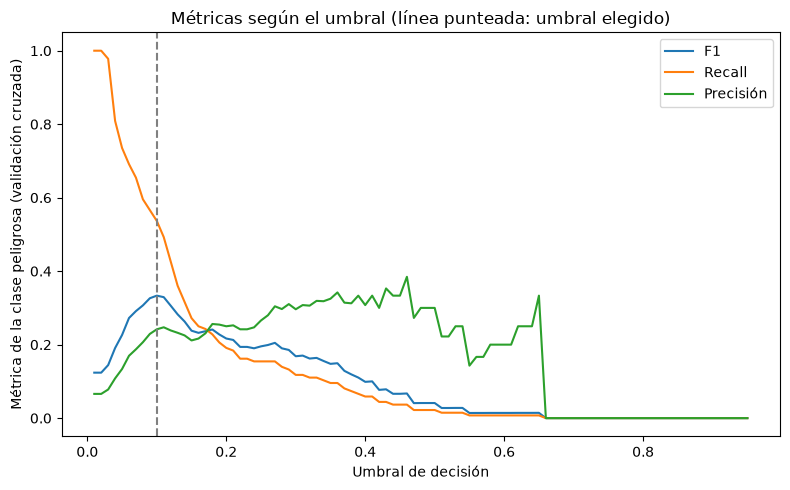

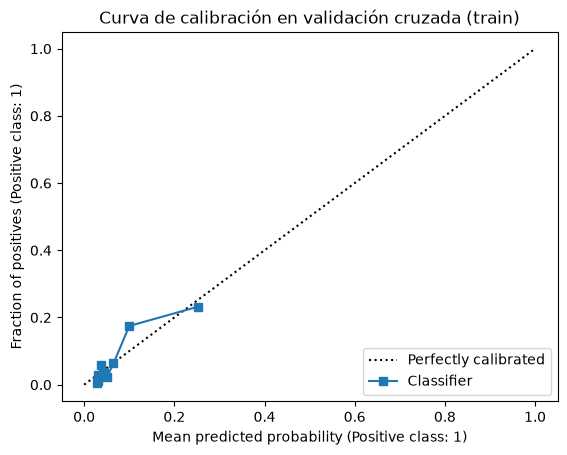

Umbral elegido: 0.1

Distribución de las probabilidades calibradas (validación cruzada):
count    2062.000
mean        0.067
std         0.077
min         0.026
25%         0.031
50%         0.039
75%         0.064
max         0.888
dtype: float64

Los 10 mejores umbrales por F1:


,Umbral,F1,Recall,Precision
9,0.10,0.333,0.537,0.242
10,0.11,0.329,0.493,0.247
8,0.09,0.326,0.566,0.229
7,0.08,0.307,0.596,0.207
11,0.12,0.306,0.426,0.239
6,0.07,0.291,0.654,0.187
12,0.13,0.282,0.360,0.232
5,0.06,0.272,0.691,0.170
13,0.14,0.263,0.316,0.225
17,0.18,0.241,0.228,0.256


In [9]:
plt.figure(figsize=(8, 5))
plt.plot(tabla_umbrales['Umbral'], tabla_umbrales['F1'], label='F1')
plt.plot(tabla_umbrales['Umbral'], tabla_umbrales['Recall'], label='Recall')
plt.plot(tabla_umbrales['Umbral'], tabla_umbrales['Precision'], label='Precisión')
plt.axvline(umbral, linestyle='--', color='gray')
plt.xlabel('Umbral de decisión')
plt.ylabel('Métrica de la clase peligrosa (validación cruzada)')
plt.title('Métricas según el umbral (línea punteada: umbral elegido)')
plt.legend()
plt.tight_layout()
plt.savefig(RUTA_FIGURAS + '04_f1_recall_precision_vs_umbral.png', bbox_inches='tight', dpi=150)
plt.show()

CalibrationDisplay.from_predictions(y_train, probabilidades_cv, n_bins=10, strategy='quantile')
plt.title('Curva de calibración en validación cruzada (train)')
plt.savefig(RUTA_FIGURAS + '04_curva_calibracion_cv.png', bbox_inches='tight', dpi=150)
plt.show()

print('Umbral elegido:', umbral)
print('\nDistribución de las probabilidades calibradas (validación cruzada):')
print(pd.Series(probabilidades_cv).describe().round(3))
print('\nLos 10 mejores umbrales por F1:')
tabla_umbrales.sort_values('F1', ascending=False).head(10).round(3)

**Lo que notamos.** El umbral elegido es **0,10**, con un F1 de 0,333, un recall de 0,537 y una precisión de 0,242 en validación cruzada. A diferencia de la primera versión, ahora la curva es razonable: el F1 sube y baja de forma gradual alrededor del máximo (0,326 con 0,09, 0,329 con 0,11, 0,307 con 0,08 y 0,306 con 0,12), y no un precipicio de un solo escalón. Las probabilidades calibradas se reparten entre 0,026 y 0,888, con una mediana de 0,039 y un promedio de 0,067: la gran mayoría de los turnos reciben una probabilidad baja y unos pocos reciben una alta.

En la curva de calibración los puntos quedan cerca de la diagonal. Los turnos a los que el modelo les da en promedio un 25% de riesgo fueron peligrosos alrededor del 23% de las veces, y los que reciben un 10% lo fueron cerca del 17%, o sea que en esa zona el modelo subestima un poco. Hay que tener presente que ni siquiera en el grupo de mayor riesgo se pasa de más o menos uno de cada cuatro turnos peligrosos: el modelo ordena, pero no logra decir "este turno es seguro que será peligroso".

## Evaluación en test

Aquí abrimos `test.csv` (recordemos que ya lo habíamos abierto una vez con la primera versión del modelo; ver la nota del principio). Entrenamos el modelo final con todo train, calculamos las probabilidades en test, aplicamos el umbral elegido con train y reportamos las métricas. También comparamos con un `DummyClassifier` que siempre responde "sin peligro", para mostrar que el accuracy solo no dice nada.

In [10]:
metricas_cv = {}
for nombre_metrica in ['F1', 'Recall', 'Precision', 'ROC_AUC', 'Accuracy', 'Precision_promedio', 'Brier']:
    metricas_cv[nombre_metrica] = float(fila_final[nombre_metrica])
print('Métricas de validación cruzada (umbral', umbral, '):')
print(pd.Series(metricas_cv).round(3))

test = pd.read_csv(RUTA_DATOS + 'test.csv')
X_test = test[decisiones['rasgos']]
y_test = test['class']
print('\nX_test:', X_test.shape, '| turnos peligrosos en test:', y_test.sum())

# 1. Entrenamos con todo train; 2. probabilidades en test; 3. aplicamos el umbral elegido con train
modelo_final.fit(X_train, y_train)
probabilidades_test = modelo_final.predict_proba(X_test)[:, 1]
y_pred = (probabilidades_test >= umbral).astype(int)

print(classification_report(y_test, y_pred, target_names=['Sin peligro', 'Peligroso'], zero_division=0))
verdaderos_negativos, falsos_positivos, falsos_negativos, verdaderos_positivos = confusion_matrix(y_test, y_pred).ravel()
print('Turnos peligrosos detectados:', verdaderos_positivos, 'de', y_test.sum(), '| no detectados:', falsos_negativos)
print('Falsas alarmas:', falsos_positivos, 'de', verdaderos_negativos + falsos_positivos, 'turnos sin peligro')

metricas_test = calcular_metricas(y_test, y_pred, probabilidades_test)
print('Métricas en test:')
print(pd.Series(metricas_test).round(3))
print('Probabilidad media predicha en test:', round(probabilidades_test.mean(), 3), '| proporción real de peligrosos:', round(y_test.mean(), 3))

Métricas de validación cruzada (umbral 0.1 ):
F1                    0.333
Recall                0.537
Precision             0.242
ROC_AUC               0.777
Accuracy              0.858
Precision_promedio    0.206
Brier                 0.058
dtype: float64

X_test: (516, 5) | turnos peligrosos en test: 34
              precision    recall  f1-score   support

 Sin peligro       0.96      0.88      0.92       482
   Peligroso       0.22      0.47      0.30        34

    accuracy                           0.85       516
   macro avg       0.59      0.68      0.61       516
weighted avg       0.91      0.85      0.88       516

Turnos peligrosos detectados: 16 de 34 | no detectados: 18
Falsas alarmas: 57 de 482 turnos sin peligro
Métricas en test:
F1                    0.299
Recall                0.471
Precision             0.219
ROC_AUC               0.744
Accuracy              0.855
Precision_promedio    0.192
Brier                 0.059
dtype: float64
Probabilidad media predicha en te

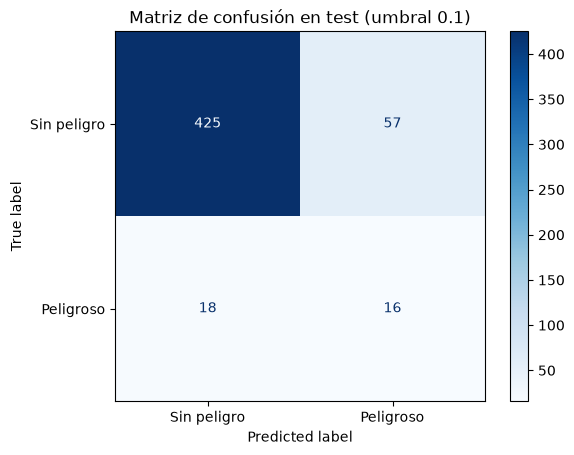

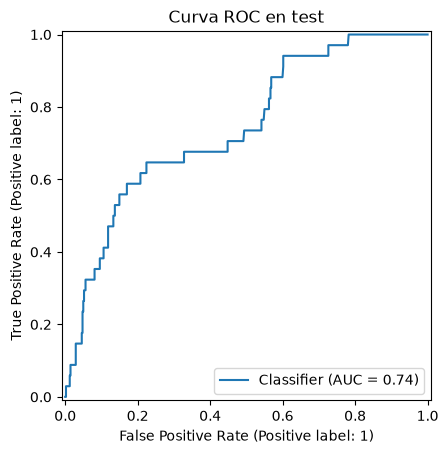

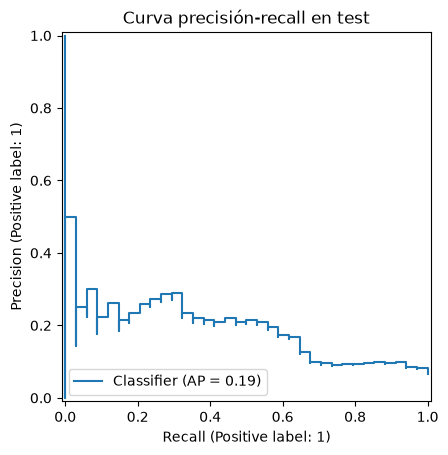

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Sin peligro', 'Peligroso'], cmap=plt.cm.Blues)
plt.title('Matriz de confusión en test (umbral ' + str(umbral) + ')')
plt.savefig(RUTA_FIGURAS + '04_matriz_confusion_test.png', bbox_inches='tight', dpi=150)
plt.show()

RocCurveDisplay.from_predictions(y_test, probabilidades_test)
plt.title('Curva ROC en test')
plt.savefig(RUTA_FIGURAS + '04_curva_roc_test.png', bbox_inches='tight', dpi=150)
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, probabilidades_test)
plt.title('Curva precisión-recall en test')
plt.savefig(RUTA_FIGURAS + '04_curva_precision_recall_test.png', bbox_inches='tight', dpi=150)
plt.show()

In [12]:
# Línea base: un modelo que siempre responde "sin peligro"
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

comparacion = pd.DataFrame([
    {'Modelo': 'Siempre "sin peligro"', 'Accuracy': accuracy_score(y_test, y_pred_dummy),
     'Recall': recall_score(y_test, y_pred_dummy), 'F1': f1_score(y_test, y_pred_dummy, zero_division=0)},
    {'Modelo': nombre_final + ' | ' + estrategia_final + ' | calibrado', 'Accuracy': metricas_test['Accuracy'],
     'Recall': metricas_test['Recall'], 'F1': metricas_test['F1']},
])
comparacion

,Modelo,Accuracy,Recall,F1
0,"Siempre ""sin peligro""",0.934109,0.000000,0.000000
1,SVM lineal | Submuestreo | calibrado,0.854651,0.470588,0.299065


**Lo que notamos.** En test el modelo detectó **16 de los 34 turnos peligrosos** (recall de 0,471) y dejó pasar 18. Dio **57 falsas alarmas** entre los 482 turnos sin peligro (un 11,8%), así que de sus 73 alarmas 16 fueron ciertas (precisión de 0,219). El F1 fue de 0,299, el ROC AUC de 0,744 y el Brier de 0,059, un poco mejor que los 0,0616 de decir siempre el 6,6%. La probabilidad promedio que predijo en test fue de 0,067 y la proporción real de turnos peligrosos fue de 0,066: en promedio, está bien calibrado.

Es importante decir que el F1 en test (0,299) es casi igual al de la primera versión (0,296): cambiar el enfoque **no mejoró el resultado en test, y no era ese el objetivo**. Lo que ganamos es un modelo con probabilidades que se pueden interpretar y menos falsas alarmas (57 contra 81, a cambio de detectar 4 turnos peligrosos menos). Frente a la validación cruzada (F1 de 0,333, recall de 0,537) el test queda más abajo; es lo esperable, porque el umbral se eligió con esos mismos datos de validación (algo optimista) y porque con 34 turnos peligrosos cada turno cambia el recall unos 3 puntos. El modelo que siempre responde "sin peligro" tiene un accuracy de 0,934, más alto que el de nuestro modelo (0,855), pero detecta cero turnos peligrosos.

## Exportación

Guardamos el modelo final con `joblib`. Es un modelo calibrado que ya incluye el pipeline completo (escalador, y el submuestreo, que solo actúa al entrenar y no al predecir). Además guardamos una metadata en JSON con todo lo que necesita la app para mostrar y usar el modelo: el modelo, la estrategia, la calibración, el escalador, los rasgos, el umbral, los hiperparámetros, las métricas en validación cruzada y en test, la fecha y la versión de scikit-learn.

In [13]:
joblib.dump(modelo_final, RUTA_MODELOS + 'modelo_final.joblib')

# Los hiperparámetros se pasan a texto para que el JSON no falle con tuplas o None
hiperparametros = {}
for nombre_parametro, valor in ajuste_final['Mejores_parametros'].items():
    hiperparametros[nombre_parametro] = str(valor)

metadata = {
    'modelo': nombre_final,
    'estrategia_balanceo': estrategia_final,
    'calibracion': 'sigmoide (CalibratedClassifierCV, 5 particiones)',
    'escalador': decisiones['escalador'],
    'rasgos': decisiones['rasgos'],
    'umbral': float(umbral),
    'hiperparametros': hiperparametros,
    'metricas_cv': metricas_cv,
    'metricas_test': metricas_test,
    'fecha_entrenamiento': datetime.datetime.now().isoformat(timespec='seconds'),
    'version_sklearn': sklearn.__version__,
}
with open(RUTA_MODELOS + 'metadata_modelo.json', 'w', encoding='utf-8') as archivo:
    json.dump(metadata, archivo, indent=2, ensure_ascii=False)

print(json.dumps(metadata, indent=2, ensure_ascii=False))

{
  "modelo": "SVM lineal",
  "estrategia_balanceo": "Submuestreo",
  "calibracion": "sigmoide (CalibratedClassifierCV, 5 particiones)",
  "escalador": "MinMaxScaler",
  "rasgos": [
    "gpuls",
    "nbumps",
    "nbumps2",
    "nbumps3",
    "energy"
  ],
  "umbral": 0.1,
  "hiperparametros": {
    "clf__C": "0.1"
  },
  "metricas_cv": {
    "F1": 0.3333333333333333,
    "Recall": 0.5367647058823529,
    "Precision": 0.24172185430463577,
    "ROC_AUC": 0.7770390477063099,
    "Accuracy": 0.8583899127061105,
    "Precision_promedio": 0.2064389436940618,
    "Brier": 0.05792267528943036
  },
  "metricas_test": {
    "F1": 0.29906542056074764,
    "Recall": 0.47058823529411764,
    "Precision": 0.2191780821917808,
    "ROC_AUC": 0.7443861361972175,
    "Accuracy": 0.8546511627906976,
    "Precision_promedio": 0.19169725303485693,
    "Brier": 0.059477455148986405
  },
  "fecha_entrenamiento": "2026-10-08T16:31:50",
  "version_sklearn": "1.9.1"
}


## Cargar y verificar

Como en la sección "Cargar el modelo entrenado" de clase, cargamos el archivo `.joblib` y comprobamos que predice **exactamente lo mismo** que el modelo que teníamos en memoria antes de guardarlo. Esto es lo que va a hacer la app al abrirse.

In [14]:
modelo_cargado = joblib.load(RUTA_MODELOS + 'modelo_final.joblib')
probabilidades_cargado = modelo_cargado.predict_proba(X_test)[:, 1]
y_pred_cargado = (probabilidades_cargado >= umbral).astype(int)

print('Probabilidades idénticas:', np.array_equal(probabilidades_test, probabilidades_cargado))
print('Predicciones idénticas:', np.array_equal(y_pred, y_pred_cargado))

Probabilidades idénticas: True
Predicciones idénticas: True


**Lo que notamos.** El modelo cargado desde `modelo_final.joblib` da exactamente las mismas probabilidades y las mismas predicciones que el modelo que teníamos en memoria antes de guardarlo. Eso es lo que va a hacer la app al abrirse.

## Conclusiones

- **Modelo y estrategia.** El modelo final es la SVM lineal con submuestreo y calibración sigmoide (`C=0,1`), con `MinMaxScaler` y los 5 rasgos `gpuls`, `nbumps`, `nbumps2`, `nbumps3` y `energy`. Ganó por un empate práctico con la regresión logística (F1 en validación cruzada de 0,333 contra 0,323).
- **Umbral.** 0,10, elegido con probabilidades calibradas de validación cruzada sobre train.
- **Resultados.** En validación cruzada: F1 0,333, recall 0,537, precisión 0,242 y ROC AUC 0,777. En test: F1 0,299, recall 0,471, precisión 0,219, ROC AUC 0,744 y Brier 0,059. Detecta 16 de 34 turnos peligrosos, con 57 falsas alarmas entre 482 turnos sin peligro.
- **Qué cambió respecto a la primera versión.** La primera versión (regresión logística con `C=0,01`, ajustada con F1) daba un F1 de 0,296 en test pero con probabilidades pegadas a 0,5, inservibles para la app. En esta versión ajustamos con la precisión promedio y calibramos las probabilidades; el F1 en test es prácticamente el mismo, pero ahora las probabilidades se pueden leer como riesgo (la predicha promedio fue 6,7% y la real 6,6%). Como ya habíamos visto el test de la primera versión, este test no es completamente virgen; lo decimos en el informe.
- **Qué aprendimos del desbalance.** Sin balancear los modelos no detectan casi nada, y al balancear ganamos recall pero perdemos precisión. Con este conjunto de rasgos, el modelo tiene una capacidad limitada: el Brier mejora solo cerca de un 6% frente a decir siempre el 6,6%, y ni siquiera el grupo de mayor riesgo supera más o menos una de cuatro alarmas ciertas. El resultado es útil como alerta temprana que ordena los turnos por riesgo, no como un sistema que dé certeza.
- **Limitaciones.** Solo 34 turnos peligrosos en test, así que cada acierto mueve el recall unos 3 puntos; las diferencias entre los mejores modelos son menores que el ruido; el umbral y los hiperparámetros se eligieron con la misma validación cruzada (algo de optimismo); y el test ya se había visto una vez.
- **Qué haríamos con más tiempo.** Validación cruzada anidada, más datos o más variables del monitoreo, revisar rasgos que descartamos (como `shift`, que mostró una diferencia grande de riesgo en el EDA) y probar si un modelo de árboles con probabilidades calibradas aprovecha mejor las interacciones.
- **Archivos generados.** `models/modelo_final.joblib`, `models/metadata_modelo.json`, `resultados/ajuste_hiperparametros.csv` y las figuras `04_*.png`.